## 1. Load aligned predictions for all models

`batch_metrics_zjsh_pi10102ts.yaml` filters every model's windows down to the
same time slice that a Timer-XL window (sl=768, pl=96) would also see, so all
models share **identical aligned windows**. Loaded here:

- 6 Timer-XL variants: full-shot S/MS, zero-shot S/MS, partial-15 S/MS
- 11 deep-learning baselines (CNNLSTM, LSTMGRU, STAConvBiLSTM, TCNTransformer,
  TimeXer, GTProger, GTProgerV13, in S and/or MS variants)

This notebook reproduces the alignment filter when loading `pred.npy` / `true.npy`.


In [82]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path

# notebook 位于 figures/PI10102/，TSFM 根目录在两级之上
TSFM_ROOT = Path('../..')
cfg_path = TSFM_ROOT / 'setting' / 'batch_metrics_zjsh_pi10102ts.yaml'
cfg = yaml.safe_load(cfg_path.read_text())
params = cfg.get('params', {})

target          = params['target']            # 'PI10102'
eval_steps      = int(params.get('eval_steps', 15))
data_root       = Path(params['data_root'])
results_root    = TSFM_ROOT / params.get('results_root', './results')
align_cfg       = params.get('align_eval_to') or {}
align_seq_len   = int(align_cfg['seq_len'])   # 768
align_pred_len  = int(align_cfg['pred_len'])  # 96

# Per-model entries (each carries its own seq_len/pred_len)
model_entries = {entry['name']: entry for entry in cfg['model_dirs']}

# Concatenate true series from all 4 transition CSVs (matches batch_metrics.py)
test_files = cfg['test']
file_lengths = []
true_series_per_file = []
for name in test_files:
    df = pd.read_csv(data_root / name)
    arr = df[target].to_numpy(copy=True)
    true_series_per_file.append(arr)
    file_lengths.append(len(arr))
true_series = np.concatenate(true_series_per_file, axis=0)

print(f'target={target}  eval_steps={eval_steps}')
print(f'test files = {len(test_files)},  total raw length = {len(true_series)}')
print(f'align_eval_to: seq_len={align_seq_len}  pred_len={align_pred_len}')


target=PI10102  eval_steps=15
test files = 4,  total raw length = 7138
align_eval_to: seq_len=768  pred_len=96


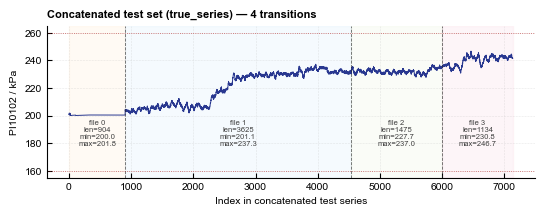

Per-segment stats:
  file 0 2103ts/PI10102_transition_020_c17_to_c5_len904.csv len=  904  min= 200.00  max= 201.78  mean= 200.36  std=  0.16  p05= 200.11  p95= 200.42
  file 1 2103ts/PI10102_transition_021_c5_to_c16_len3625.csv len= 3625  min= 201.07  max= 237.26  mean= 220.06  std= 11.88  p05= 203.48  p95= 234.16
  file 2 2103ts/PI10102_transition_022_c16_to_c14_len1475.csv len= 1475  min= 227.72  max= 236.99  mean= 232.06  std=  1.68  p05= 229.43  p95= 235.16
  file 3 2103ts/PI10102_transition_023_c14_to_c15_len1134.csv len= 1134  min= 230.81  max= 246.72  mean= 239.98  std=  3.44  p05= 233.57  p95= 243.97


In [83]:
# Plot the concatenated raw test series (true_series), with file boundaries marked.
# Use this to eyeball per-segment alarm thresholds before fixing them in ALARM_HLINES.
import matplotlib.pyplot as plt

file_offsets = np.cumsum([0] + file_lengths)  # boundary positions in true_series

fig, ax = plt.subplots(figsize=(16/2.54, 5/2.54))
ax.plot(np.arange(len(true_series)), true_series, color='#293890', linewidth=0.7, label='PI10102')

# Vertical separators + per-segment shading + filename labels
seg_colors = ['#FFF3E0', '#E3F2FD', '#F1F8E9', '#FCE4EC']
for f, name in enumerate(test_files):
    lo, hi = file_offsets[f], file_offsets[f+1]
    ax.axvspan(lo, hi, color=seg_colors[f % len(seg_colors)], alpha=0.35, zorder=0)
    if f > 0:
        ax.axvline(lo, color='#262626', linewidth=0.6, linestyle='--', alpha=0.7)
    seg = true_series[lo:hi]
    ax.text((lo + hi) / 2, np.nanmax(true_series)-50,
            f'file {f}\nlen={hi-lo}\nmin={seg.min():.1f}\nmax={seg.max():.1f}',
            ha='center', va='top', fontsize=5.5, color='#424242')

# Existing alarm reference lines
for h in ALARM_HLINES:
    ax.axhline(h, color='#B71C1C', linewidth=0.6, linestyle=':', alpha=0.7)

ax.set_xlabel('Index in concatenated test series')
ax.set_ylabel('PI10102 / kPa')
ax.set_title('Concatenated test set (true_series) — 4 transitions',
             loc='left', fontsize=8, fontweight='bold')
ax.grid(True, linewidth=0.4, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.savefig('concatenated_test_set.png', dpi=600, bbox_inches='tight')
plt.show()

# Per-segment numeric summary for picking thresholds
print('Per-segment stats:')
for f, name in enumerate(test_files):
    seg = true_series[file_offsets[f]:file_offsets[f+1]]
    print(f'  file {f} {name:40s} '
          f'len={len(seg):5d}  min={seg.min():7.2f}  max={seg.max():7.2f}  '
          f'mean={seg.mean():7.2f}  std={seg.std():6.2f}  '
          f'p05={np.percentile(seg,5):7.2f}  p95={np.percentile(seg,95):7.2f}')


inference-covered samples: 3742 / 7138 (52.4%)
  file 0: raw idx [768, 823)  len=55
  file 1: raw idx [1672, 4448)  len=2776
  file 2: raw idx [5297, 5923)  len=626
  file 3: raw idx [6772, 7057)  len=285


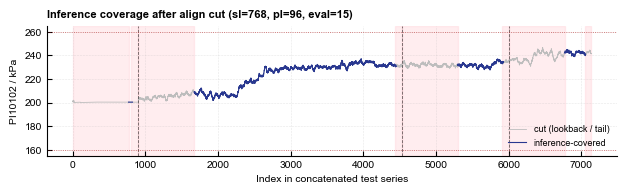


Per-segment stats on inference-covered slice:
  file 0 2103ts/PI10102_transition_020_c17_to_c5_len904.csv  len=   55  min= 200.38  max= 200.38  mean= 200.38  std=  0.00  p05= 200.38  p95= 200.38
  file 1 2103ts/PI10102_transition_021_c5_to_c16_len3625.csv  len= 2776  min= 201.97  max= 237.26  mean= 223.83  std= 10.24  p05= 205.35  p95= 234.41
  file 2 2103ts/PI10102_transition_022_c16_to_c14_len1475.csv  len=  626  min= 227.72  max= 236.99  mean= 231.91  std=  1.90  p05= 229.03  p95= 235.70
  file 3 2103ts/PI10102_transition_023_c14_to_c15_len1134.csv  len=  285  min= 239.07  max= 245.13  mean= 242.34  std=  1.16  p05= 240.14  p95= 243.78


In [84]:
# Inference-covered slice of true_series after the (768, 96) alignment cut.
# - Each segment loses its first 768 samples (lookback warm-up) and last 96 (align_pred_len).
# - The remaining predicted timestamps span [file_off+768, file_off+file_len-96+eval_steps).
import matplotlib.pyplot as plt

file_offsets = np.cumsum([0] + file_lengths)
asl, apl = align_seq_len, align_pred_len   # 768, 96

# Build per-segment inference coverage in raw-index space
infer_ranges = []
for f in range(len(file_lengths)):
    off, L = file_offsets[f], file_lengths[f]
    lo = off + asl                          # first predicted timestamp
    hi = off + L - apl + eval_steps         # one past last predicted timestamp
    infer_ranges.append((lo, hi))

# Boolean mask over true_series marking which indices have at least one prediction
infer_mask = np.zeros(len(true_series), dtype=bool)
for lo, hi in infer_ranges:
    infer_mask[lo:hi] = True

print(f'inference-covered samples: {infer_mask.sum()} / {len(true_series)} '
      f'({100*infer_mask.mean():.1f}%)')
for f, (lo, hi) in enumerate(infer_ranges):
    print(f'  file {f}: raw idx [{lo}, {hi})  len={hi-lo}')

# Plot: full series in gray, inference-covered portion highlighted, cut regions shaded red
fig, ax = plt.subplots(figsize=(16/2.54, 5/2.54))
x = np.arange(len(true_series))
ax.plot(x, true_series, color='#BDBDBD', linewidth=0.6, label='cut (lookback / tail)', zorder=2)
covered = np.where(infer_mask, true_series, np.nan)
ax.plot(x, covered, color='#293890', linewidth=0.8, label='inference-covered', zorder=3)

# Shade the cut zones at each segment's head (768) and tail (apl)
for f in range(len(file_lengths)):
    off, L = file_offsets[f], file_lengths[f]
    ax.axvspan(off, off + asl, color='#FFCDD2', alpha=0.35, zorder=1)
    ax.axvspan(off + L - apl, off + L, color='#FFCDD2', alpha=0.35, zorder=1)
    if f > 0:
        ax.axvline(off, color='#262626', linewidth=0.6, linestyle='--', alpha=0.7)

for h in ALARM_HLINES:
    ax.axhline(h, color='#B71C1C', linewidth=0.6, linestyle=':', alpha=0.7)

ax.set_xlabel('Index in concatenated test series')
ax.set_ylabel('PI10102 / kPa')
ax.set_title(f'Inference coverage after align cut (sl={asl}, pl={apl}, eval={eval_steps})',
             loc='left', fontsize=8, fontweight='bold')
ax.legend(loc='lower right', fontsize=6.5, frameon=False)
ax.grid(True, linewidth=0.4, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Per-segment stats restricted to the inference-covered slice
print('\nPer-segment stats on inference-covered slice:')
for f, (lo, hi) in enumerate(infer_ranges):
    seg = true_series[lo:hi]
    print(f'  file {f} {test_files[f]:40s}  len={len(seg):5d}  '
          f'min={seg.min():7.2f}  max={seg.max():7.2f}  '
          f'mean={seg.mean():7.2f}  std={seg.std():6.2f}  '
          f'p05={np.percentile(seg,5):7.2f}  p95={np.percentile(seg,95):7.2f}')


### Per-model loader (window-build + alignment filter)

In [85]:
def build_window_starts(seq_len, pred_len, file_lengths):
    usable = [max(0, L - seq_len - pred_len + 1) for L in file_lengths]
    cum = np.cumsum([0] + usable)
    offsets = np.cumsum([0] + file_lengths)
    starts = np.zeros(cum[-1], dtype=np.int64)
    file_idx = np.zeros(cum[-1], dtype=np.int64)
    for gi in range(cum[-1]):
        f = int(np.searchsorted(cum[1:], gi, side='right'))
        starts[gi] = offsets[f] + (gi - cum[f]) + seq_len
        file_idx[gi] = f
    return starts, file_idx


def align_window_mask(window_starts, file_idx_arr, file_lengths, asl, apl):
    offsets = np.cumsum([0] + list(file_lengths))
    file_off = offsets[file_idx_arr]
    file_len = np.array(file_lengths, dtype=np.int64)[file_idx_arr]
    return (window_starts >= file_off + asl) & (window_starts <= file_off + file_len - apl)


def _load_npy(name, kind):
    entry = model_entries[name]
    p = results_root / entry['result_dir'] / f'{kind}.npy'
    if not p.exists():
        print(f'WARNING: {p} not found')
        return None
    arr = np.load(p)
    if arr.ndim == 3:
        arr = arr[:, :, -1]   # target column is last
    sl = int(entry['seq_len']); pl = int(entry['pred_len'])
    ws, fi = build_window_starts(sl, pl, file_lengths)
    if arr.shape[0] != ws.shape[0]:
        print(f'WARN: {name} {kind}: {arr.shape[0]} rows but expected {ws.shape[0]}')
        return None
    keep = align_window_mask(ws, fi, file_lengths, align_seq_len, align_pred_len)
    return arr[keep][:, :eval_steps]


def load_pred(n): return _load_npy(n, 'pred')
def load_true(n): return _load_npy(n, 'true')

# Aligned-window bookkeeping (same indexing for every model)
ws_full, fi_full = build_window_starts(align_seq_len, align_pred_len, file_lengths)
keep_full = align_window_mask(ws_full, fi_full, file_lengths, align_seq_len, align_pred_len)
window_starts_aligned = ws_full[keep_full]
file_idx_aligned       = fi_full[keep_full]
N_aligned              = window_starts_aligned.shape[0]

# Per-file segment ranges in aligned-patch index space (used to slice plots
# to a single transition without crossing file boundaries)
file_segs = {}
for f in range(len(file_lengths)):
    in_f = np.where(file_idx_aligned == f)[0]
    if in_f.size:
        file_segs[f] = (int(in_f[0]), int(in_f[-1]))
print(f'aligned windows: {N_aligned}')
for f, (lo, hi) in file_segs.items():
    print(f'  file {f}  raw_len={file_lengths[f]}  patch_idx=[{lo}, {hi}]  ({hi-lo+1} windows)')


aligned windows: 3686
  file 0  raw_len=904  patch_idx=[0, 40]  (41 windows)
  file 1  raw_len=3625  patch_idx=[41, 2802]  (2762 windows)
  file 2  raw_len=1475  patch_idx=[2803, 3414]  (612 windows)
  file 3  raw_len=1134  patch_idx=[3415, 3685]  (271 windows)


### Load all 15 model predictions

In [86]:
# Timer-XL — 6 variants (full-shot / zero-shot / partial-15, each S & MS)
pred_txl_s          = load_pred('Timer-XL-S')
pred_txl_ms         = load_pred('Timer-XL-MS')
pred_txl_zs_s       = load_pred('Timer-XL-Zeroshot-S')
pred_txl_zs_ms      = load_pred('Timer-XL-Zeroshot-MS')
pred_txl_p15_s      = load_pred('Timer-XL-Partial15-S')
pred_txl_p15_ms     = load_pred('Timer-XL-Partial15-MS')

# Baselines (S features)
pred_cnnlstm_s      = load_pred('CNNLSTM-S')
# pred_dipcalstm_s    = load_pred('DiPCALSTM-S')
pred_lstmgru_s      = load_pred('LSTMGRU-S')
pred_staconv_s      = load_pred('STAConvBiLSTM-S')
pred_tcn_s          = load_pred('TCNTransformer-S')

# Baselines (MS features)
pred_cnnlstm_ms     = load_pred('CNNLSTM-MS')
# pred_dipcalstm_ms   = load_pred('DiPCALSTM-MS')
pred_lstmgru_ms     = load_pred('LSTMGRU-MS')
pred_staconv_ms     = load_pred('STAConvBiLSTM-MS')
pred_tcn_ms         = load_pred('TCNTransformer-MS')
pred_timexer_ms     = load_pred('TimeXer-MS')
pred_gtproger_ms    = load_pred('GTProger-MS')
pred_gtprogerv13_ms = load_pred('GTProgerV13-MS')

# Ground truth — identical for every aligned model; load once via Timer-XL-MS
plot_true = load_true('Timer-XL-MS')
plot_pred = pred_txl_ms

print(f'plot_true shape: {plot_true.shape}')
print(f'plot_pred shape: {plot_pred.shape}')
print('Timer-XL variants:')
for n, a in [('Timer-XL-S',       pred_txl_s),     ('Timer-XL-MS',       pred_txl_ms),
             ('Timer-XL-ZS-S',    pred_txl_zs_s),  ('Timer-XL-ZS-MS',    pred_txl_zs_ms),
             ('Timer-XL-P15-S',   pred_txl_p15_s), ('Timer-XL-P15-MS',   pred_txl_p15_ms)]:
    print(f'  {n:18s}  shape={None if a is None else a.shape}')


plot_true shape: (3686, 15)
plot_pred shape: (3686, 15)
Timer-XL variants:
  Timer-XL-S          shape=(3686, 15)
  Timer-XL-MS         shape=(3686, 15)
  Timer-XL-ZS-S       shape=(3686, 15)
  Timer-XL-ZS-MS      shape=(3686, 15)
  Timer-XL-P15-S      shape=(3686, 15)
  Timer-XL-P15-MS     shape=(3686, 15)


## 2. Plotting helpers
Same layout as `figures/PCA101A/plot_fault_prognosis.ipynb`, with the default
ylabel switched to PI10102 / kPa.

In [87]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def build_true45_from_patches(plot_true, idx, seq_len=30, pred_len=15):
    plot_true = np.asarray(plot_true, dtype=float)
    N, P = plot_true.shape
    assert P == pred_len
    assert idx >= seq_len - 1, f'idx={idx} too small, need >= {seq_len - 1}'
    hist = np.array([plot_true[idx - seq_len + k, 0] for k in range(seq_len)], dtype=float)
    fut = plot_true[idx, :pred_len].astype(float)
    return np.concatenate([hist, fut], axis=0)


def build_pred45_from_patch(plot_pred, idx, seq_len=30, pred_len=15):
    plot_pred = np.asarray(plot_pred, dtype=float)
    pred = plot_pred[idx, :pred_len].astype(float)
    pred_45 = np.full(seq_len + pred_len, np.nan, dtype=float)
    pred_45[seq_len:seq_len + pred_len] = pred
    return pred_45


def fault_window_plot_datetime(true_45, pred_45, start_time, freq='min',
                                fault_at_idx=30, hlines=None,
                                ylabel='PI10102 Value / (kPa)', title=None,
                                out_path=None, y_min=None, y_max=None,
                                extra_preds=None, figsize_cm=(9.5, 5),
                                legend_ncol=1):
    true_45 = np.asarray(true_45, dtype=float)
    pred_45 = np.asarray(pred_45, dtype=float)
    if true_45.shape[0] != pred_45.shape[0]:
        raise ValueError('true_45 and pred_45 must have same length')

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
        'font.size': 7.5, 'axes.labelsize': 7.5, 'axes.titlesize': 7.5,
        'axes.titleweight': 'bold', 'axes.linewidth': 0.8,
        'xtick.labelsize': 7.5, 'ytick.labelsize': 7.5,
        'xtick.direction': 'in', 'ytick.direction': 'in',
        'legend.fontsize': 7.5, 'legend.frameon': False,
        'grid.linestyle': '--', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,
        'pdf.fonttype': 42, 'ps.fonttype': 42,
    })

    x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=len(true_45), freq=freq)
    fault_at = x_vals[fault_at_idx]

    fig, ax = plt.subplots(figsize=(figsize_cm[0] / 2.54, figsize_cm[1] / 2.54))

    if extra_preds:
        for item in extra_preds:
            ed, el, ec = item[0], item[1], item[2]
            st = item[3] if len(item) > 3 else {}
            ax.plot(x_vals, np.asarray(ed, dtype=float), label=el,
                    linewidth=st.get('linewidth', 1.25), color=ec,
                    linestyle=st.get('linestyle', '-'),
                    alpha=st.get('alpha', 1), zorder=st.get('zorder', 1))

    ax.plot(x_vals, true_45, label='Observation',
            linewidth=1.25, color='#293890', alpha=1, zorder=2)
    ax.axvline(fault_at, label='Prognosis start',
               linestyle=':', color='#262626', linewidth=1.0, alpha=0.8, zorder=1)

    if hlines:
        for i, y in enumerate(hlines):
            ax.axhline(y, linestyle='--', color='#262626', linewidth=0.8, alpha=0.7,
                       label='Alarm limit' if i == 0 else None, zorder=1)

    if y_min is not None and y_max is not None:
        ax.set_ylim(float(y_min), float(y_max))
    else:
        y_parts = [true_45, pred_45]
        if extra_preds:
            for item in extra_preds:
                y_parts.append(np.asarray(item[0], dtype=float))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            ymin, ymax = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (ymax - ymin) * 0.05 if ymin != ymax else (abs(ymin) * 0.1 or 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

    ax.set_xlabel('Time (HH:MM)', fontsize=7.5)
    ax.set_ylabel(ylabel, fontsize=7.5)
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)

    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc='center right', fontsize=7.5, ncol=legend_ncol)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8); ax.spines['bottom'].set_linewidth(0.8)
    plt.subplots_adjust(left=0.15, right=0.65, top=0.88, bottom=0.15)

    if out_path:
        fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig)
    else:
        plt.show()


def reconstruct_signal(plot_data, start_t, end_t, pred_len=15):
    plot_data = np.asarray(plot_data, dtype=float)
    N = plot_data.shape[0]
    total_len = end_t - start_t + 1
    result = np.full(total_len, np.nan)
    j = pred_len - 1
    i_lo = max(0, start_t - j); i_hi = min(N - 1, end_t - j)
    if i_lo <= i_hi:
        i_range = np.arange(i_lo, i_hi + 1)
        out_pos = i_range + j - start_t
        result[out_pos] = plot_data[i_range, j]
    return result


def plot_range_comparison(plot_true, plot_pred, start_t, end_t,
                          pred_len=15, start_time=None, freq='min',
                          hlines=None, ylabel='PI10102 Value / (kPa)',
                          title=None, out_path=None,
                          y_min=None, y_max=None, y_padding=0.05, y_limits=None,
                          figsize_cm=(8, 6), show_xtick_labels=True,
                          extra_preds=None, legend_ncol=1):
    true_cont = reconstruct_signal(plot_true, start_t, end_t, pred_len=pred_len)
    pred_cont = reconstruct_signal(plot_pred, start_t, end_t, pred_len=pred_len)
    total_len = len(true_cont)

    if start_time is not None:
        x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=total_len, freq=freq)
        use_dt = True
    else:
        x_vals = np.arange(start_t, end_t + 1)
        use_dt = False

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
        'font.size': 7.5, 'axes.labelsize': 7.5, 'axes.titlesize': 7.5,
        'axes.titleweight': 'bold', 'axes.linewidth': 0.8,
        'xtick.direction': 'in', 'ytick.direction': 'in',
        'legend.fontsize': 7.5, 'legend.frameon': False,
        'grid.linestyle': '--', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,
        'pdf.fonttype': 42, 'ps.fonttype': 42,
    })

    w_cm, h_cm = figsize_cm
    fig, ax = plt.subplots(figsize=(w_cm / 2.54, h_cm / 2.54))

    if extra_preds:
        for item in extra_preds:
            ed, el, ec = item[0], item[1], item[2]
            st = item[3] if len(item) > 3 else {}
            extra_cont = reconstruct_signal(ed, start_t, end_t, pred_len=pred_len)
            ax.plot(x_vals, extra_cont, label=el,
                    linewidth=st.get('linewidth', 0.8), color=ec,
                    linestyle=st.get('linestyle', '-'),
                    alpha=st.get('alpha', 1), zorder=st.get('zorder', 1))

    ax.plot(x_vals, true_cont, label='Observation',
            linewidth=0.8, color='#293890', alpha=0.9, zorder=2)

    if hlines:
        for idx_h, y in enumerate(hlines):
            ax.axhline(y, linestyle='--', color='#262626', linewidth=0.8, alpha=0.7,
                       label='Alarm limit' if idx_h == 0 else None, zorder=1)

    if y_limits is not None:
        ax.set_ylim(float(y_limits[0]), float(y_limits[1]))
    else:
        y_parts = [true_cont, pred_cont]
        if extra_preds:
            for item in extra_preds:
                y_parts.append(reconstruct_signal(item[0], start_t, end_t, pred_len=pred_len))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            ymin_v, ymax_v = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (ymax_v - ymin_v) * y_padding if ymin_v != ymax_v else (abs(ymin_v) * y_padding or 1.0)
            ax.set_ylim(ymin_v - pad, ymax_v + pad)

    if use_dt:
        if total_len <= 60:    maj, mn = 10, 1
        elif total_len <= 180: maj, mn = 30, 5
        elif total_len <= 720: maj, mn = 60, 10
        elif total_len <= 1440: maj, mn = 120, 30
        else:                   maj, mn = 360, 60
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=maj))
        ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=mn))
        if show_xtick_labels:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            plt.setp(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        ax.set_xlabel('Time (HH:MM)', fontsize=7.5)
    else:
        ax.set_xlabel('Patch Index', fontsize=7.5)

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    ax.margins(x=0.02)
    ax.set_ylabel(ylabel, fontsize=7.5)
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc='center right', fontsize=7.5, ncol=legend_ncol)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8); ax.spines['bottom'].set_linewidth(0.8)
    plt.subplots_adjust(left=0.1, right=0.78, top=0.88, bottom=0.15)

    if out_path:
        fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig)
        print(f'Saved to {out_path}')
    else:
        plt.show()


## 3. Color & style registry
Two TSFM fine-tunes (Timer-XL-S/MS, red highlight) plus 13 deep-learning
prognosis baselines (S and MS variants).

In [88]:
S_BASELINE = dict(linestyle='--', linewidth=0.8, alpha=0.75, zorder=1)
S_TSFM     = dict(linestyle='-',  linewidth=1.4, alpha=1.0,  zorder=3)

# Baselines
C_CNNLSTM   = '#78909C'   # blue-gray
C_DIPCALSTM = '#8D6E63'   # brown
C_LSTMGRU   = '#9E9E9E'   # gray
C_STACONV   = '#FFB300'   # amber
C_TCN       = '#66BB6A'   # green
C_TIMEXER   = '#5C6BC0'   # indigo
C_GTPROGER  = '#FF7043'   # deep orange
C_GTPV13    = '#7CB342'   # lime

# S variants slightly lighter than MS for visual pairing
C_CNNLSTM_S   = '#B0BEC5'; C_DIPCALSTM_S = '#BCAAA4'
C_LSTMGRU_S   = '#CFCFCF'; C_STACONV_S   = '#FFD54F'
C_TCN_S       = '#A5D6A7'

# Timer-XL — three families, each with light (S) / dark (MS) shades
# Full-shot fine-tune  -> red
C_TXL_S      = '#FF5252'; C_TXL_MS      = '#B71C1C'
# Zero-shot            -> teal/cyan
C_TXL_ZS_S   = '#4DD0E1'; C_TXL_ZS_MS   = '#006064'
# Partial-15 fine-tune -> purple
C_TXL_P15_S  = '#BA68C8'; C_TXL_P15_MS  = '#4A148C'

ALARM_HLINES = [260.0, 160.0]        # H, L for PI10102
DATA_ROOT_NAME = 'PI10102'


## 4. Fault window plot — single window, multi-model overlay

The 4 transitions are short (904, 3625, 1475, 1134 samples) and PI10102 stays
inside [160, 260], so true alarms don't fire. We pick a window in the longest
transition (file 1 = `transition_021_c5_to_c16`) for a representative view.

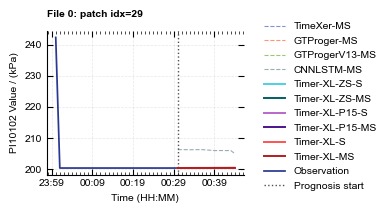

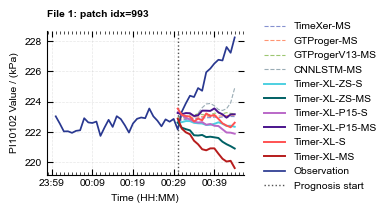

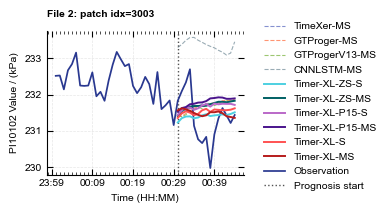

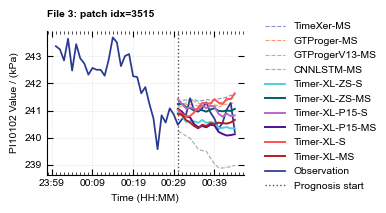

In [89]:
display_seq = 30           # 30-min lookback for the visualization
display_pred = eval_steps  # 15-step forecast horizon

def _bp(arr, idx):
    return build_pred45_from_patch(arr, idx, display_seq, display_pred)

# Per-file single-window snapshot. Pick a window inside each file's aligned segment.
WINDOW_OFFSETS = {0: 10, 1: 952, 2: 200, 3: 100}

for f, (seg_lo, seg_hi) in file_segs.items():
    seg_len = seg_hi - seg_lo + 1
    off = min(WINDOW_OFFSETS.get(f, seg_len // 2), seg_len - 1)
    idx = seg_lo + off
    if idx < display_seq - 1:
        idx = max(seg_lo + display_seq - 1, idx)
    if idx > seg_hi:
        print(f'  file {f}: segment too short for display_seq={display_seq}, skipping')
        continue

    true_45 = build_true45_from_patches(plot_true, idx, seq_len=display_seq, pred_len=display_pred)
    pred_45 = build_pred45_from_patch(plot_pred, idx, seq_len=display_seq, pred_len=display_pred)

    extra = [
        # --- Deep-learning baselines (dashed) ---
        (_bp(pred_timexer_ms,      idx), 'TimeXer-MS',     C_TIMEXER,   S_BASELINE),
        (_bp(pred_gtproger_ms,     idx), 'GTProger-MS',    C_GTPROGER,  S_BASELINE),
        (_bp(pred_gtprogerv13_ms,  idx), 'GTProgerV13-MS', C_GTPV13,    S_BASELINE),
        (_bp(pred_cnnlstm_ms,      idx), 'CNNLSTM-MS',     C_CNNLSTM,   S_BASELINE),
        # --- Timer-XL Zero-shot (teal, solid) ---
        (_bp(pred_txl_zs_s,        idx), 'Timer-XL-ZS-S',  C_TXL_ZS_S,  S_TSFM),
        (_bp(pred_txl_zs_ms,       idx), 'Timer-XL-ZS-MS', C_TXL_ZS_MS, S_TSFM),
        # --- Timer-XL Partial-15 (purple, solid) ---
        (_bp(pred_txl_p15_s,       idx), 'Timer-XL-P15-S', C_TXL_P15_S, S_TSFM),
        (_bp(pred_txl_p15_ms,      idx), 'Timer-XL-P15-MS',C_TXL_P15_MS,S_TSFM),
        # --- Timer-XL Full-shot (red, solid) ---
        (_bp(pred_txl_s,           idx), 'Timer-XL-S',     C_TXL_S,     S_TSFM),
        (_bp(pred_txl_ms,          idx), 'Timer-XL-MS',    C_TXL_MS,    S_TSFM),
    ]

    fault_window_plot_datetime(
        true_45=true_45, pred_45=pred_45,
        start_time='2024-01-01 00:00:00', freq='min',
        fault_at_idx=display_seq,
        # hlines=ALARM_HLINES,
        title=f'File {f}: patch idx={idx}',
        extra_preds=extra,
        figsize_cm=(10, 5), legend_ncol=1,
        # out_path=f'a_fault_window_file{f}_{idx}.png',
    )


## 5. Range comparison — full transition reconstruction

`reconstruct_signal` keeps only the last (15-th) forecast step of each window,
giving a contiguous predicted curve. We slice to a single transition's aligned
range to avoid crossing file boundaries.

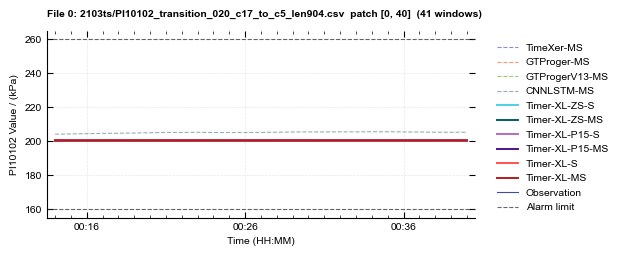

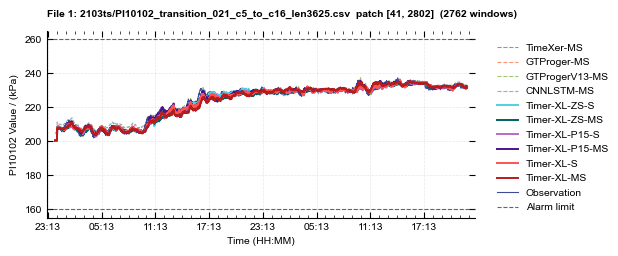

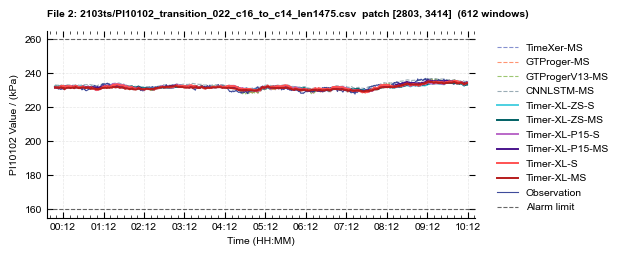

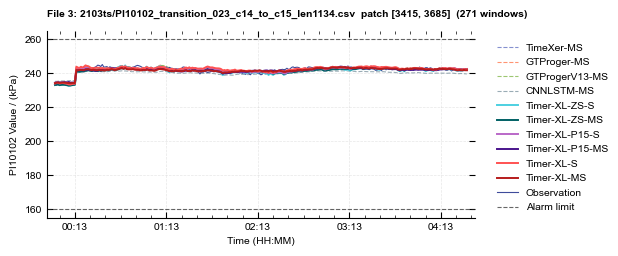

In [90]:
# Per-file range comparison: one figure per transition, time axis local to each file.
# Each file's predicted span starts at its own '00:00' so HH:MM ticks count minutes
# from the start of that transition (easy to read off alarm-trigger times per file).
extra_template = [
    # Deep-learning baselines
    (pred_timexer_ms,      'TimeXer-MS',      C_TIMEXER,   S_BASELINE),
    (pred_gtproger_ms,     'GTProger-MS',     C_GTPROGER,  S_BASELINE),
    (pred_gtprogerv13_ms,  'GTProgerV13-MS',  C_GTPV13,    S_BASELINE),
    (pred_cnnlstm_ms,      'CNNLSTM-MS',      C_CNNLSTM,   S_BASELINE),
    # Timer-XL Zero-shot
    (pred_txl_zs_s,        'Timer-XL-ZS-S',   C_TXL_ZS_S,  S_TSFM),
    (pred_txl_zs_ms,       'Timer-XL-ZS-MS',  C_TXL_ZS_MS, S_TSFM),
    # Timer-XL Partial-15
    (pred_txl_p15_s,       'Timer-XL-P15-S',  C_TXL_P15_S, S_TSFM),
    (pred_txl_p15_ms,      'Timer-XL-P15-MS', C_TXL_P15_MS,S_TSFM),
    # Timer-XL Full-shot
    (pred_txl_s,           'Timer-XL-S',      C_TXL_S,     S_TSFM),
    (pred_txl_ms,          'Timer-XL-MS',     C_TXL_MS,    S_TSFM),
]

for f, (start_t, end_t) in file_segs.items():
    span = end_t - start_t + 1
    if span < 2:
        print(f'  file {f}: only {span} patch(es) in segment, skipping')
        continue

    plot_range_comparison(
        plot_true=plot_true, plot_pred=plot_pred,
        start_t=start_t, end_t=end_t, pred_len=eval_steps,
        start_time='2024-01-01 00:00:00', freq='min',
        hlines=ALARM_HLINES, show_xtick_labels=True,
        title=(f'File {f}: {test_files[f]}  '
               f'patch [{start_t}, {end_t}]  ({span} windows)'),
        figsize_cm=(16, 6.5), extra_preds=extra_template, legend_ncol=1,
        # out_path=f'a_range_file{f}.png',
    )


## 9. Small multiples — one panel per model

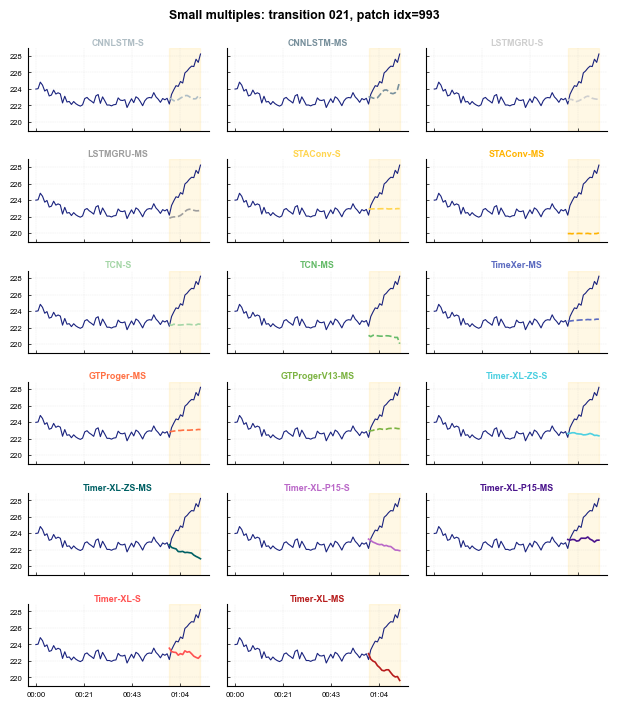

Saved a_small_multiples_021.png


In [96]:
from matplotlib.ticker import MaxNLocator

display_seq = 60
display_pred = eval_steps
file1_lo, file1_hi = file_segs[1]
idx = file1_lo + 952
assert idx >= display_seq - 1

true_45 = build_true45_from_patches(plot_true, idx, seq_len=display_seq, pred_len=display_pred)
x_vals = pd.date_range(start='2024-01-01 00:00:00', periods=display_seq + display_pred, freq='min')

models_grid = [
    (pred_cnnlstm_s,     'CNNLSTM-S',       C_CNNLSTM_S,   '--'),
    (pred_cnnlstm_ms,    'CNNLSTM-MS',      C_CNNLSTM,     '--'),
    (pred_lstmgru_s,     'LSTMGRU-S',       C_LSTMGRU_S,   '--'),
    (pred_lstmgru_ms,    'LSTMGRU-MS',      C_LSTMGRU,     '--'),
    (pred_staconv_s,     'STAConv-S',       C_STACONV_S,   '--'),
    (pred_staconv_ms,    'STAConv-MS',      C_STACONV,     '--'),
    (pred_tcn_s,         'TCN-S',           C_TCN_S,       '--'),
    (pred_tcn_ms,        'TCN-MS',          C_TCN,         '--'),
    (pred_timexer_ms,    'TimeXer-MS',      C_TIMEXER,     '--'),
    (pred_gtproger_ms,   'GTProger-MS',     C_GTPROGER,    '--'),
    (pred_gtprogerv13_ms,'GTProgerV13-MS',  C_GTPV13,      '--'),
    # Timer-XL — three families, each S and MS
    (pred_txl_zs_s,      'Timer-XL-ZS-S',   C_TXL_ZS_S,    '-'),
    (pred_txl_zs_ms,     'Timer-XL-ZS-MS',  C_TXL_ZS_MS,   '-'),
    (pred_txl_p15_s,     'Timer-XL-P15-S',  C_TXL_P15_S,   '-'),
    (pred_txl_p15_ms,    'Timer-XL-P15-MS', C_TXL_P15_MS,  '-'),
    (pred_txl_s,         'Timer-XL-S',      C_TXL_S,       '-'),
    (pred_txl_ms,        'Timer-XL-MS',     C_TXL_MS,      '-'),
]

ncols = 3
nrows = int(np.ceil(len(models_grid) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16/2.54, 18/2.54),
                          sharex=True, sharey=True)
axes_flat = axes.flatten()

# Global y limits (data only — alarm hlines disabled)
all_v = [np.nanmin(true_45), np.nanmax(true_45)]
for data, *_ in models_grid:
    p = build_pred45_from_patch(data, idx, display_seq, display_pred)
    all_v.append(np.nanmin(p[display_seq:])); all_v.append(np.nanmax(p[display_seq:]))
g_min, g_max = min(all_v), max(all_v)
g_pad = (g_max - g_min) * 0.08
g_ylim = (g_min - g_pad, g_max + g_pad)

for i, (data, label, color, ls) in enumerate(models_grid):
    ax = axes_flat[i]
    pred_45 = build_pred45_from_patch(data, idx, display_seq, display_pred)
    ax.plot(x_vals, true_45, color='#1A237E', linewidth=0.8, zorder=5)
    ax.plot(x_vals, pred_45, color=color, linestyle=ls, linewidth=1.2, zorder=6)
    ax.axvspan(x_vals[display_seq], x_vals[-1], alpha=0.10, color='#FFC107', zorder=0)
    ax.set_title(label, fontsize=6.5, fontweight='bold', pad=2, color=color)
    ax.set_ylim(g_ylim)
    ax.tick_params(axis='both', labelsize=5.5, direction='in', length=2, width=0.5)
    ax.grid(True, linewidth=0.3, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))

for j in range(len(models_grid), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f'Small multiples: transition 021, patch idx={idx}',
             fontsize=9, fontweight='bold', y=0.995)
plt.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.04, hspace=0.35, wspace=0.1)
fig.savefig('a_small_multiples_021.png', dpi=600, facecolor='white')
plt.show()
print('Saved a_small_multiples_021.png')


## 6. Dual-panel: Timer-XL fine-tunes vs deep-learning baselines

In [91]:
# start_t, end_t = file_segs[1]
# duration = end_t - start_t
# x_vals = pd.date_range(start='2024-01-01 00:00:00', periods=duration + 1, freq='min')
# obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

# tsfm_models = [
#     (pred_txl_s,  'Timer-XL-S',  C_TXL_S,  '-', 1.4),
#     (pred_txl_ms, 'Timer-XL-MS', C_TXL_MS, '-', 1.4),
# ]
# baseline_models = [
#     (pred_cnnlstm_s,     'CNNLSTM-S',       C_CNNLSTM_S,   '--', 0.7),
#     (pred_cnnlstm_ms,    'CNNLSTM-MS',      C_CNNLSTM,     '--', 0.8),
#     # (pred_dipcalstm_s,   'DiPCALSTM-S',     C_DIPCALSTM_S, '--', 0.7),
#     # (pred_dipcalstm_ms,  'DiPCALSTM-MS',    C_DIPCALSTM,   '--', 0.8),
#     (pred_lstmgru_s,     'LSTMGRU-S',       C_LSTMGRU_S,   '--', 0.7),
#     (pred_lstmgru_ms,    'LSTMGRU-MS',      C_LSTMGRU,     '--', 0.8),
#     (pred_staconv_s,     'STAConvBiLSTM-S', C_STACONV_S,   '--', 0.7),
#     (pred_staconv_ms,    'STAConvBiLSTM-MS',C_STACONV,     '--', 0.8),
#     (pred_tcn_s,         'TCNTransformer-S',C_TCN_S,       '--', 0.7),
#     (pred_tcn_ms,        'TCNTransformer-MS',C_TCN,        '--', 0.8),
#     (pred_timexer_ms,    'TimeXer-MS',      C_TIMEXER,     '--', 0.9),
#     (pred_gtproger_ms,   'GTProger-MS',     C_GTPROGER,    '--', 1.0),
#     (pred_gtprogerv13_ms,'GTProgerV13-MS',  C_GTPV13,      '--', 1.0),
# ]

# plt.rcParams.update({
#     'font.family': 'sans-serif',
#     'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
#     'font.size': 7.5, 'axes.labelsize': 7.5, 'axes.titlesize': 8,
#     'axes.titleweight': 'bold', 'axes.linewidth': 0.8,
#     'xtick.direction': 'in', 'ytick.direction': 'in',
#     'legend.fontsize': 6.5, 'legend.frameon': False,
# })

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16/2.54, 10/2.54), sharex=True,
#                                 gridspec_kw={'hspace': 0.2})

# for ax, group, title in [(ax1, tsfm_models, '(a) Timer-XL based'),
#                           (ax2, baseline_models, '(b) Deep-learning prognosis baselines')]:
#     ax.plot(x_vals, obs, label='Observation', linewidth=1.0, color='#1A237E', zorder=10)
#     for data, label, color, ls, lw in group:
#         sig = reconstruct_signal(data, start_t, end_t, pred_len=eval_steps)
#         ax.plot(x_vals, sig, label=label, color=color, linestyle=ls, linewidth=lw, zorder=3)
#     for h in ALARM_HLINES:
#         ax.axhline(h, color='#262626', linewidth=0.6, linestyle=':', alpha=0.5)
#     ax.set_title(title, loc='left', fontsize=8, fontweight='bold', pad=4)
#     ax.set_ylabel('kPa', fontsize=7.5)
#     ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
#     ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
#     ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=6,
#               ncol=1, handlelength=2.0, frameon=False)
#     ax.tick_params(axis='both', which='major', direction='in', length=4, width=0.8)

# ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=360))
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax2.set_xlabel('Synthetic time (HH:MM)', fontsize=7.5)
# plt.subplots_adjust(right=0.85)
# plt.tight_layout()
# fig.savefig('a_dual_panel_021.png', dpi=600, bbox_inches='tight', facecolor='white')
# plt.show()
# print('Saved a_dual_panel_021.png')


## 7. Prediction envelope — baseline band + highlighted Timer-XL

In [92]:
# start_t, end_t = file_segs[1]
# x_vals = pd.date_range(start='2024-01-01 00:00:00', periods=end_t - start_t + 1, freq='min')
# obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

# baseline_arrs = [pred_cnnlstm_s, pred_cnnlstm_ms, pred_dipcalstm_s, pred_dipcalstm_ms,
#                  pred_lstmgru_s, pred_lstmgru_ms, pred_staconv_s, pred_staconv_ms,
#                  pred_tcn_s, pred_tcn_ms, pred_timexer_ms, pred_gtproger_ms,
#                  pred_gtprogerv13_ms]
# sigs = np.array([reconstruct_signal(a, start_t, end_t, pred_len=eval_steps) for a in baseline_arrs])
# env_lo  = np.nanmin(sigs, axis=0)
# env_hi  = np.nanmax(sigs, axis=0)
# env_med = np.nanmedian(sigs, axis=0)

# highlight = [
#     (pred_gtproger_ms,    'GTProger-MS',  C_GTPROGER, '--', 1.2),
#     (pred_gtprogerv13_ms, 'GTProgerV13',  C_GTPV13,   '--', 1.2),
#     (pred_txl_s,          'Timer-XL-S',   C_TXL_S,    '-',  1.5),
#     (pred_txl_ms,         'Timer-XL-MS',  C_TXL_MS,   '-',  1.5),
# ]

# fig, ax = plt.subplots(figsize=(16/2.54, 6/2.54))
# ax.fill_between(x_vals, env_lo, env_hi, alpha=0.18, color='#9E9E9E',
#                 label='Baseline range', zorder=1)
# ax.plot(x_vals, env_med, color='#BDBDBD', linewidth=0.6, linestyle=':',
#         label='Baseline median', zorder=2)
# ax.plot(x_vals, obs, label='Observation', linewidth=1.2, color='#1A237E', zorder=10)
# for data, label, color, ls, lw in highlight:
#     sig = reconstruct_signal(data, start_t, end_t, pred_len=eval_steps)
#     ax.plot(x_vals, sig, label=label, color=color, linestyle=ls, linewidth=lw, zorder=5)
# for h in ALARM_HLINES:
#     ax.axhline(h, color='#262626', linewidth=0.5, linestyle=':', alpha=0.5)

# ax.set_ylabel('PI10102 Value / (kPa)', fontsize=7.5)
# ax.set_xlabel('Synthetic time (HH:MM)', fontsize=7.5)
# ax.set_title('Prediction envelope: 13 baselines vs Timer-XL', loc='left',
#              fontsize=8, fontweight='bold', pad=6)
# ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=360))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
# ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
# ax.legend(loc='upper right', ncol=2, fontsize=6.5, handlelength=2.5)
# ax.tick_params(direction='in', length=4, width=0.8)
# plt.tight_layout()
# fig.savefig('a_envelope_021.png', dpi=600, facecolor='white')
# plt.show()
# print('Saved a_envelope_021.png')


## 8. Error fingerprint heatmap — |pred − obs| across 15 models

In [93]:
# from mpl_toolkits.axes_grid1 import make_axes_locatable
# import matplotlib.colors as mcolors

# start_t, end_t = file_segs[1]
# duration = end_t - start_t
# obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

# all_models = [
#     (pred_cnnlstm_s,     'CNNLSTM-S'),
#     (pred_cnnlstm_ms,    'CNNLSTM-MS'),
#     # (pred_dipcalstm_s,   'DiPCALSTM-S'),
#     # (pred_dipcalstm_ms,  'DiPCALSTM-MS'),
#     (pred_lstmgru_s,     'LSTMGRU-S'),
#     (pred_lstmgru_ms,    'LSTMGRU-MS'),
#     (pred_staconv_s,     'STAConv-S'),
#     (pred_staconv_ms,    'STAConv-MS'),
#     (pred_tcn_s,         'TCN-S'),
#     (pred_tcn_ms,        'TCN-MS'),
#     (pred_timexer_ms,    'TimeXer-MS'),
#     (pred_gtproger_ms,   'GTProger-MS'),
#     (pred_gtprogerv13_ms,'GTProgerV13-MS'),
#     (pred_txl_s,         'Timer-XL-S'),
#     (pred_txl_ms,        'Timer-XL-MS'),
# ]
# n_models = len(all_models)
# err = np.full((n_models, duration + 1), np.nan)
# for i, (data, _) in enumerate(all_models):
#     err[i] = np.abs(reconstruct_signal(data, start_t, end_t, pred_len=eval_steps) - obs)
# labels = [m[1] for m in all_models]

# fig, ax = plt.subplots(figsize=(16/2.54, 9/2.54))
# vmax = np.nanpercentile(err, 95)
# norm = mcolors.Normalize(vmin=0, vmax=vmax)
# im = ax.imshow(err, aspect='auto', cmap='viridis', norm=norm,
#                interpolation='nearest', origin='upper')
# ax.axhline(12.5, color='white', linewidth=2.5)   # separator: baselines (0-12) vs Timer-XL (13-14)
# ax.text(-duration*0.06, 6.0,  'DLP Baselines', fontsize=7, fontweight='bold',
#         ha='center', va='center', rotation=90, color='#424242')
# ax.text(-duration*0.06, 13.5, 'Timer-XL', fontsize=7, fontweight='bold',
#         ha='center', va='center', rotation=90, color='#424242')

# ax.set_yticks(range(n_models))
# ax.set_yticklabels(labels, fontsize=6.5)

# n_ticks = 7
# tick_pos = np.linspace(0, duration, n_ticks, dtype=int)
# times = pd.date_range(start='2024-01-01 00:00:00', periods=duration + 1, freq='min')
# ax.set_xticks(tick_pos)
# ax.set_xticklabels([times[t].strftime('%H:%M') for t in tick_pos], fontsize=6.5)
# ax.set_xlabel('Synthetic time (HH:MM)', fontsize=7.5)
# ax.set_title('Prediction-error fingerprint  |pred − obs|', loc='left',
#              fontsize=8, fontweight='bold', pad=6)

# divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='2%', pad=0.08)
# cbar = fig.colorbar(im, cax=cax)
# cbar.set_label('Absolute error (kPa)', fontsize=7)
# cbar.ax.tick_params(labelsize=6.5)
# ax.tick_params(axis='both', length=0)
# plt.subplots_adjust(left=0.13, right=0.92, top=0.88, bottom=0.15)
# fig.savefig('a_error_heatmap_021.png', dpi=600, facecolor='white')
# plt.show()
# print('Saved a_error_heatmap_021.png')


## 10. Rolling-MAE ribbon over the longest transition

In [95]:
# start_t, end_t = file_segs[1]
# duration = end_t - start_t
# x_vals = pd.date_range(start='2024-01-01 00:00:00', periods=duration + 1, freq='min')
# obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

# models_mae = [
#     (pred_cnnlstm_s,     'CNNLSTM-S',     C_CNNLSTM_S,   '--'),
#     (pred_cnnlstm_ms,    'CNNLSTM-MS',    C_CNNLSTM,     '--'),
#     # (pred_dipcalstm_s,   'DiPCALSTM-S',   C_DIPCALSTM_S, '--'),
#     # (pred_dipcalstm_ms,  'DiPCALSTM-MS',  C_DIPCALSTM,   '--'),
#     (pred_lstmgru_s,     'LSTMGRU-S',     C_LSTMGRU_S,   '--'),
#     (pred_lstmgru_ms,    'LSTMGRU-MS',    C_LSTMGRU,     '--'),
#     (pred_staconv_s,     'STAConv-S',     C_STACONV_S,   '--'),
#     (pred_staconv_ms,    'STAConv-MS',    C_STACONV,     '--'),
#     (pred_tcn_s,         'TCN-S',         C_TCN_S,       '--'),
#     (pred_tcn_ms,        'TCN-MS',        C_TCN,         '--'),
#     (pred_timexer_ms,    'TimeXer-MS',    C_TIMEXER,     '--'),
#     (pred_gtproger_ms,   'GTProger-MS',   C_GTPROGER,    '--'),
#     (pred_gtprogerv13_ms,'GTProgerV13',   C_GTPV13,      '--'),
#     (pred_txl_s,         'Timer-XL-S',    C_TXL_S,       '-'),
#     (pred_txl_ms,        'Timer-XL-MS',   C_TXL_MS,      '-'),
# ]

# window = 30   # 30-min rolling window
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16/2.54, 10/2.54), sharex=True,
#                                 gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.25})
# fig.suptitle('Rolling MAE — transition 021', fontsize=10, fontweight='bold', y=0.98)

# ax1.plot(x_vals, obs, color='#1A237E', linewidth=1.0, label='Observation')
# for h in ALARM_HLINES:
#     ax1.axhline(h, color='#262626', linewidth=0.6, linestyle=':', alpha=0.5)
# ax1.set_ylabel('kPa', fontsize=7.5)
# ax1.set_title('(a) Observation', loc='left', fontsize=8, fontweight='bold', pad=4)
# ax1.grid(True, linewidth=0.5, alpha=0.3, linestyle='--')
# ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# for data, label, color, ls in models_mae:
#     sig = reconstruct_signal(data, start_t, end_t, pred_len=eval_steps)
#     abs_err = np.abs(sig - obs)
#     roll = pd.Series(abs_err).rolling(window, min_periods=1, center=True).mean().values
#     lw = 1.2 if ls == '-' else 0.6
#     ax2.plot(x_vals, roll, color=color, linestyle=ls, linewidth=lw, label=label, alpha=0.9)

# ax2.set_ylabel('Rolling MAE', fontsize=7.5)
# ax2.set_xlabel('Synthetic time (HH:MM)', fontsize=7.5)
# ax2.set_title(f'(b) {window}-min rolling MAE', loc='left', fontsize=8, fontweight='bold', pad=4)
# ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=360))
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax2.grid(True, linewidth=0.5, alpha=0.3, linestyle='--')
# ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
# ax2.legend(loc='upper right', ncol=4, fontsize=5.5, columnspacing=1.0, handlelength=2.0)

# for ax in [ax1, ax2]:
#     ax.tick_params(direction='in', length=4, width=0.8, labelsize=6.5)

# plt.subplots_adjust(left=0.1, right=0.95, top=0.90, bottom=0.10)
# fig.savefig('a_rolling_mae_021.png', dpi=600, facecolor='white')
# plt.show()
# print('Saved a_rolling_mae_021.png')
